# 03 V2 数据分析 & 可视化

**目标**：
1. 对 V2 原始结果做评分，并输出 `results/v2/processed/scored_results.csv`
2. 按模型 / 变体 / 长度汇总准确率、输出长度、token 与成本效率
3. 生成 V2 NIAH 热力图、长度曲线与位置偏差图
4. 检查 16K / 32K 的置信区间，判断波动是否稳定
5. 所有图表只写入 `results/v2/figures/`，不覆盖 V1

In [1]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'v2' and PROJECT_ROOT.parent.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import src.metrics_v2 as metrics_v2_module
import src.visualize as visualize_module

importlib.reload(metrics_v2_module)
importlib.reload(visualize_module)

from src.metrics_v2 import (
    print_v2_summary_with_status,
    score_results_v2,
    summarize_call_status,
    summarize_v2,
    summarize_variant_matrix,
    filter_eval_valid,
    )
from src.visualize import (
    plot_accuracy_by_length,
    plot_accuracy_by_length_with_ci,
    plot_depth_accuracy_curve,
    plot_efficiency_tradeoff,
    plot_niah_heatmap,
    plot_niah_heatmap_interactive,
    plot_multihop_by_hops,
    plot_position_bias,
    )

print(f'V2 分析模块加载完毕，PROJECT_ROOT={PROJECT_ROOT}')

V2 分析模块加载完毕，PROJECT_ROOT=/Users/melody/Desktop/Eval


## Step 1：加载 V2 原始结果并评分

In [2]:
raw_path = PROJECT_ROOT / 'results/v2/raw/raw_results.csv'
dataset_path = PROJECT_ROOT / 'data/processed/v2/niah_dataset.jsonl'
multihop_dataset_path = PROJECT_ROOT / 'data/processed/v2/multihop_dataset.jsonl'
processed_dir = PROJECT_ROOT / 'results/v2/processed'
figures_dir = PROJECT_ROOT / 'results/v2/figures'

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

if not raw_path.exists():
    raise FileNotFoundError('请先运行 notebooks/v2/02_eval_runner_v2.ipynb 获取 V2 原始结果')
if not dataset_path.exists():
    raise FileNotFoundError('请先运行 notebooks/v2/01_data_preparation_v2.ipynb 生成 V2 数据集')

df_raw_all = pd.read_csv(raw_path)
dataset_df = pd.read_json(dataset_path, lines=True)
multihop_dataset_df = pd.read_json(multihop_dataset_path, lines=True) if multihop_dataset_path.exists() else pd.DataFrame()

if 'task' not in df_raw_all.columns:
    df_raw_all['task'] = 'niah'
df_raw_all['task'] = df_raw_all['task'].fillna('niah')

df_raw_niah = df_raw_all[df_raw_all['task'] == 'niah'].copy()
df_raw_multihop = df_raw_all[df_raw_all['task'] != 'niah'].copy()

models = sorted(df_raw_all['model'].dropna().unique().tolist())
expected_niah_per_model = len(dataset_df)
expected_niah_total = expected_niah_per_model * len(models)
actual_niah_total = len(df_raw_niah)
missing_niah_total = expected_niah_total - actual_niah_total
is_complete = missing_niah_total == 0
coverage_pct = actual_niah_total / expected_niah_total * 100 if expected_niah_total else 0.0
coverage_by_length = (
    df_raw_niah.groupby(['model', 'context_length']).size().unstack(fill_value=0)
    if not df_raw_niah.empty else pd.DataFrame()
    )

print(f'原始结果总数: {len(df_raw_all)} 条, 模型: {models}')
print(f'NIAH 期望结果: {expected_niah_total} 条 ({expected_niah_per_model} 条/模型)')
print(f'NIAH 覆盖率: {coverage_pct:.1f}%')
if not coverage_by_length.empty:
    print('\n各模型 x 上下文长度 覆盖数:')
    print(coverage_by_length.to_string())
if not is_complete:
    print(f'\n⚠️ 当前 NIAH 仍缺少 {missing_niah_total} 条结果，图表仅可用于趋势分析。')
if not df_raw_multihop.empty:
    print(f'\n已检测到 multi_hop 结果: {len(df_raw_multihop)} 条')
elif not multihop_dataset_df.empty:
    print(f'\n已准备 multi_hop 数据集: {len(multihop_dataset_df)} 条，当前尚未评测。')

df = score_results_v2(df_raw_all)
df_niah = df[df['task'] == 'niah'].copy()
df_niah_valid = filter_eval_valid(df_niah)
df_multihop = df[df['task'] != 'niah'].copy()

df.to_csv(processed_dir / 'scored_results.csv', index=False, encoding='utf-8-sig')
model_summary = summarize_v2(df_niah_valid) if not df_niah_valid.empty else pd.DataFrame()
variant_summary = summarize_variant_matrix(df_niah_valid) if not df_niah_valid.empty else pd.DataFrame()
length_summary = summarize_v2(df_niah_valid, group_cols=['model', 'context_length']) if not df_niah_valid.empty else pd.DataFrame()
call_status = summarize_call_status(df_niah) if not df_niah.empty else pd.DataFrame()
task_summary = summarize_v2(df, group_cols=['model', 'task']) if not df.empty else pd.DataFrame()

if not model_summary.empty:
    model_summary.to_csv(processed_dir / 'summary_by_model_niah_valid_only.csv', index=False, encoding='utf-8-sig')
if not variant_summary.empty:
    variant_summary.to_csv(processed_dir / 'summary_by_model_variant.csv', index=False, encoding='utf-8-sig')
if not length_summary.empty:
    length_summary.to_csv(processed_dir / 'summary_by_model_length.csv', index=False, encoding='utf-8-sig')
if not call_status.empty:
    call_status.to_csv(processed_dir / 'summary_call_status.csv', index=False, encoding='utf-8-sig')

print('\n✅ V2 评分结果已保存到 results/v2/processed/（主口径: eval_valid）')
if not df_niah.empty:
    print_v2_summary_with_status(df_niah)
if not df_multihop.empty and not task_summary.empty:
    print('multi_hop 汇总：')
    display(task_summary[task_summary['task'] != 'niah'])

原始结果总数: 1114 条, 模型: ['deepseek', 'kimi', 'qwen']
NIAH 期望结果: 1050 条 (350 条/模型)
NIAH 覆盖率: 100.0%

各模型 x 上下文长度 覆盖数:
context_length  2000   4000   8000   16000  32000
model                                            
deepseek           70     70     70     70     70
kimi               70     70     70     70     70
qwen               70     70     70     70     70

已检测到 multi_hop 结果: 64 条

✅ V2 评分结果已保存到 results/v2/processed/（主口径: eval_valid）

调用状态（NIAH）：


   model   n  eval_valid  content_filter  infra_api_failed  eval_valid_pct  content_filter_pct
deepseek 350         328               0                22            93.7                 0.0
    kimi 350         319              31                 0            91.1                 8.9
    qwen 350         319               0                31            91.1                 0.0

                      V2 评测结果摘要
   model   n  em_pct  contains_pct  contains_ci_low_pct  contains_ci_high_pct  avg_latency_s  avg_response_chars  avg_completion_tokens  cost_per_contains_hit_cny
deepseek 350    61.1          90.6                 87.1                  93.2           0.73                 6.1                    4.8                     0.0057
    kimi 350    81.7          86.0                 82.0                  89.2           2.05                 6.2                    6.2                     0.6388
    qwen 350    80.0          81.4                 77.0                  85.2           7.14      

,model,task,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,cost_per_em_hit_cny,contains_per_1k_output_tokens
0,deepseek,multi_hop,32,43.8,65.6,48.3,79.6,1.36,6.9,4.2,0.1107,0.0053,0.0079,256.55
3,qwen,multi_hop,32,68.8,68.8,51.4,82.0,0.90,4.9,4.1,0.6243,0.0284,0.0284,204.69


## Step 2：覆盖率、变体分布与失败样本

In [3]:
variant_coverage = df_niah.groupby(['model', 'variant']).size().unstack(fill_value=0)
variant_accuracy = (
    df_niah.groupby(['model', 'variant'])['contains_score'].mean().unstack(fill_value=0) * 100
    ).round(1)
domain_accuracy = (
    df_niah.groupby(['model', 'domain'])['contains_score'].mean().unstack(fill_value=0) * 100
    ).round(1)

print('按变体覆盖数：')
display(variant_coverage)

print('按变体 Contains 准确率 (%)：')
display(variant_accuracy)

print('按领域 Contains 准确率 (%)：')
display(domain_accuracy)

multi_key_slice = df_niah[df_niah['variant'] == 'multi_key'].copy()
if not multi_key_slice.empty:
    print('multi_key 样本中的 num_needles 分布：')
    display(multi_key_slice.groupby(['model', 'num_needles']).size().unstack(fill_value=0))

failures = df_niah[df_niah['contains_score'] == 0].copy()
print(f'失败样本: {len(failures)} / {len(df_niah)} ({len(failures) / max(len(df_niah), 1) * 100:.1f}%)')
if not failures.empty:
    cols = [
        'model', 'variant', 'domain', 'context_length', 'depth_pct',
        'num_needles', 'expected_answer', 'model_response',
        ]
    display(failures[cols].head(10))

按变体覆盖数：


variant,multi_key,numeric_confusable,style_aligned
model,,,
deepseek,120,114,116
kimi,120,114,116
qwen,120,114,116


按变体 Contains 准确率 (%)：


variant,multi_key,numeric_confusable,style_aligned
model,,,
deepseek,91.7,86.0,94.0
kimi,91.7,76.3,89.7
qwen,91.7,62.3,89.7


按领域 Contains 准确率 (%)：


domain,finance,healthcare,logistics,manufacturing,retail
model,,,,,
deepseek,91.8,97.2,68.4,90.9,95.3
kimi,90.9,94.4,50.0,87.5,88.4
qwen,90.9,94.4,7.9,87.5,88.4


multi_key 样本中的 num_needles 分布：


num_needles,3
model,
deepseek,120
kimi,120
qwen,120


失败样本: 147 / 1050 (14.0%)


,model,variant,domain,context_length,depth_pct,num_needles,expected_answer,model_response
11,deepseek,numeric_confusable,logistics,2000,10.0,1,92.1%,24小时履约率。
45,deepseek,numeric_confusable,logistics,2000,75.0,1,92.1%,24小时履约率。
80,deepseek,multi_key,manufacturing,4000,10.0,3,2025年6月18日,NaN
86,deepseek,multi_key,finance,4000,10.0,3,9.4亿元,NaN
101,deepseek,numeric_confusable,logistics,4000,50.0,1,92.1%,24小时履约率。
105,deepseek,multi_key,manufacturing,4000,50.0,3,2025年6月18日,NaN
113,deepseek,numeric_confusable,finance,4000,75.0,1,23.7%,NaN
114,deepseek,multi_key,manufacturing,4000,75.0,3,2025年6月18日,NaN
121,deepseek,multi_key,manufacturing,4000,90.0,3,2025年6月18日,NaN
130,deepseek,multi_key,healthcare,4000,100.0,3,42张,NaN


## Step 3：模型摘要、变体矩阵与 16K / 32K 稳定性

这里优先看三个问题：
1. 哪个模型总体命中率最高
2. 哪个模型输出更短、单位命中成本更低
3. 16K / 32K 的置信区间是否足够稳定

In [4]:
summary_cols = [
    'model', 'n', 'em_pct', 'contains_pct',
    'contains_ci_low_pct', 'contains_ci_high_pct',
    'avg_latency_s', 'avg_response_chars', 'avg_completion_tokens',
    'total_cost_cny', 'cost_per_contains_hit_cny', 'contains_per_1k_output_tokens',
    ]

print('模型级摘要：')
display(model_summary[summary_cols].sort_values('contains_pct', ascending=False))

print(f'评分结果文件: {processed_dir / "scored_results.csv"}')
print(f'模型摘要文件: {processed_dir / "summary_by_model.csv"}')

模型级摘要：


,model,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,contains_per_1k_output_tokens
0,deepseek,328,65.2,96.6,94.1,98.1,0.78,6.5,5.1,1.8211,0.0057,227.70
1,kimi,319,89.7,94.4,91.3,96.4,2.25,6.8,6.8,192.2936,0.6388,154.47
2,qwen,319,87.8,89.3,85.5,92.3,7.83,6.6,6.1,11.3116,0.0397,179.95


评分结果文件: /Users/melody/Desktop/Eval/results/v2/processed/scored_results.csv
模型摘要文件: /Users/melody/Desktop/Eval/results/v2/processed/summary_by_model.csv


In [5]:
if not variant_summary.empty:
    print('模型 x 变体摘要：')
    display(
        variant_summary[
            [
                'model', 'variant', 'n', 'contains_pct',
                'contains_ci_low_pct', 'contains_ci_high_pct',
                'avg_completion_tokens', 'cost_per_contains_hit_cny',
                ]
            ].sort_values(['variant', 'contains_pct'], ascending=[True, False])
        )

    variant_pivot = variant_summary.pivot(index='model', columns='variant', values='contains_pct').round(1)
    print('变体准确率矩阵 (%)：')
    display(variant_pivot)

stability_focus = length_summary[length_summary['context_length'].isin([16000, 32000])].copy()
if not stability_focus.empty:
    print('16K / 32K 稳定性观察：')
    display(
        stability_focus[
            [
                'model', 'context_length', 'n', 'contains_pct',
                'contains_ci_low_pct', 'contains_ci_high_pct',
                'avg_completion_tokens', 'cost_per_contains_hit_cny',
                ]
            ].sort_values(['context_length', 'contains_pct'], ascending=[True, False])
        )

模型 x 变体摘要：


,model,variant,n,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_completion_tokens,cost_per_contains_hit_cny
0,deepseek,multi_key,110,100.0,96.6,100.0,4.7,0.0064
3,kimi,multi_key,110,100.0,96.6,100.0,7.4,0.6330
6,qwen,multi_key,110,100.0,96.6,100.0,7.5,0.0372
1,deepseek,numeric_confusable,109,89.9,82.8,94.3,6.2,0.0057
4,kimi,numeric_confusable,105,82.9,74.5,88.9,7.2,0.7143
7,qwen,numeric_confusable,105,67.6,58.2,75.8,5.6,0.0516
2,deepseek,style_aligned,109,100.0,96.6,100.0,4.4,0.0051
5,kimi,style_aligned,104,100.0,96.4,100.0,5.7,0.5819
8,qwen,style_aligned,104,100.0,96.4,100.0,5.1,0.0342


变体准确率矩阵 (%)：


variant,multi_key,numeric_confusable,style_aligned
model,,,
deepseek,100.0,89.9,100.0
kimi,100.0,82.9,100.0
qwen,100.0,67.6,100.0


16K / 32K 稳定性观察：


,model,context_length,n,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_completion_tokens,cost_per_contains_hit_cny
8,kimi,16000,64,96.9,89.3,99.1,6.8,0.8441
3,deepseek,16000,64,93.8,85.0,97.5,4.8,0.0078
13,qwen,16000,64,90.6,81.0,95.6,5.9,0.0521
9,kimi,32000,61,100.0,94.1,100.0,6.9,1.5534
4,deepseek,32000,70,98.6,92.3,99.7,4.9,0.0135
14,qwen,32000,61,95.1,86.5,98.3,6.4,0.0973


## Step 4：V2 NIAH 热力图

主图仍然是 `context_length × depth_pct` 热力图，但现在所有输出只落到 `results/v2/figures/`。

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_deepseek.png


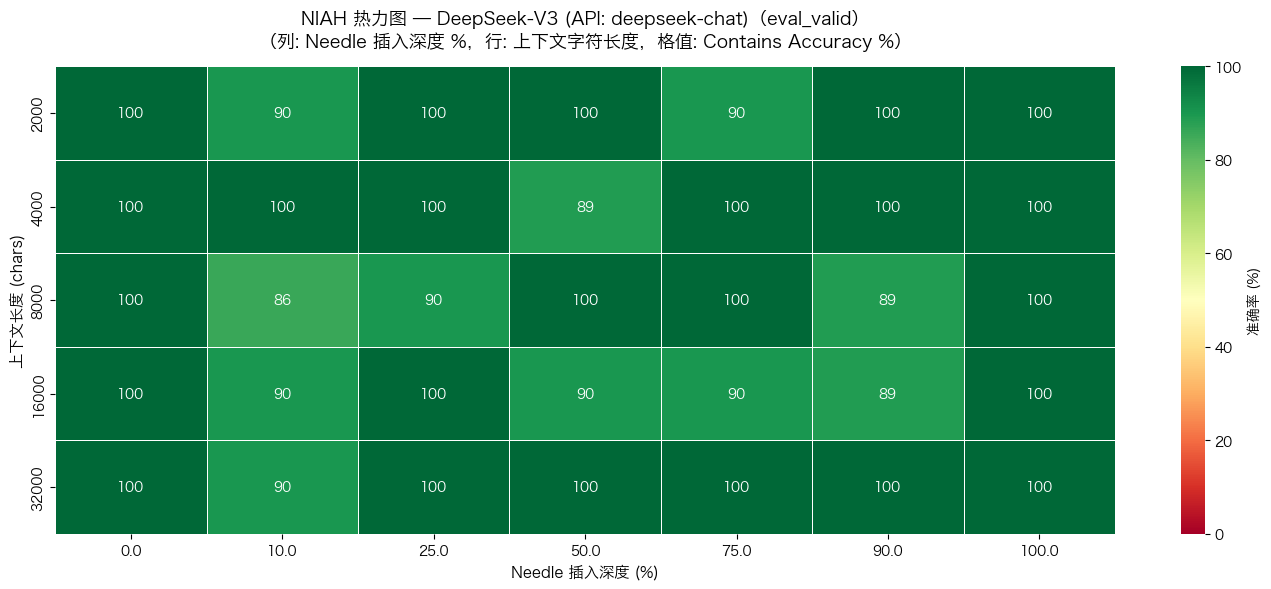

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_qwen.png


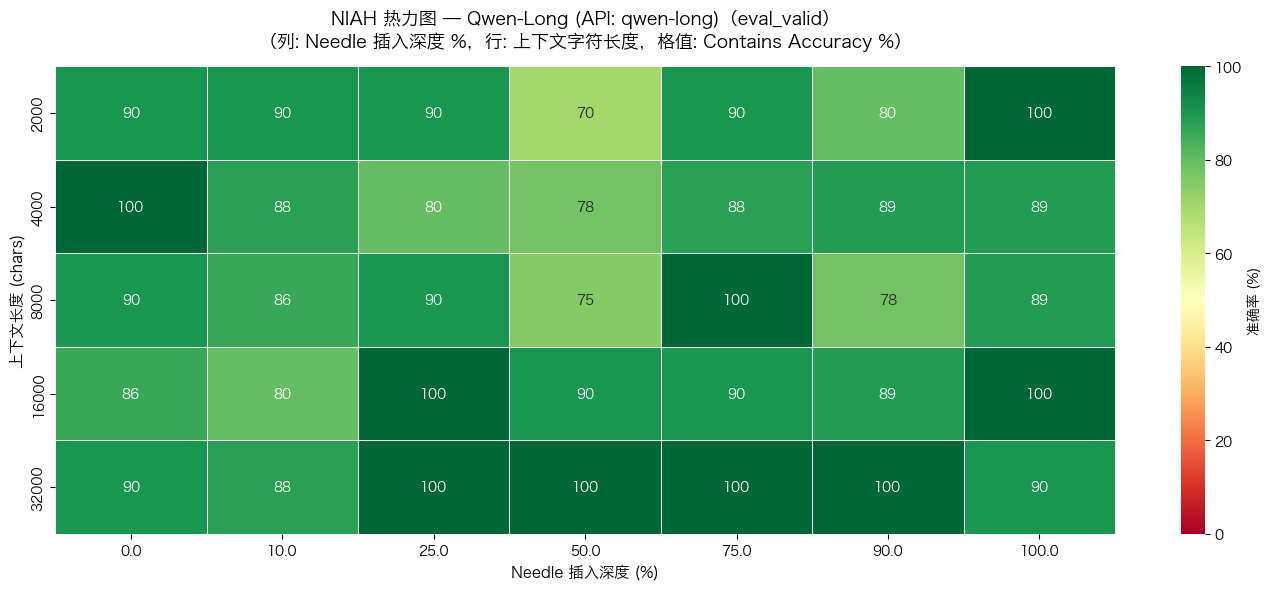

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_kimi.png


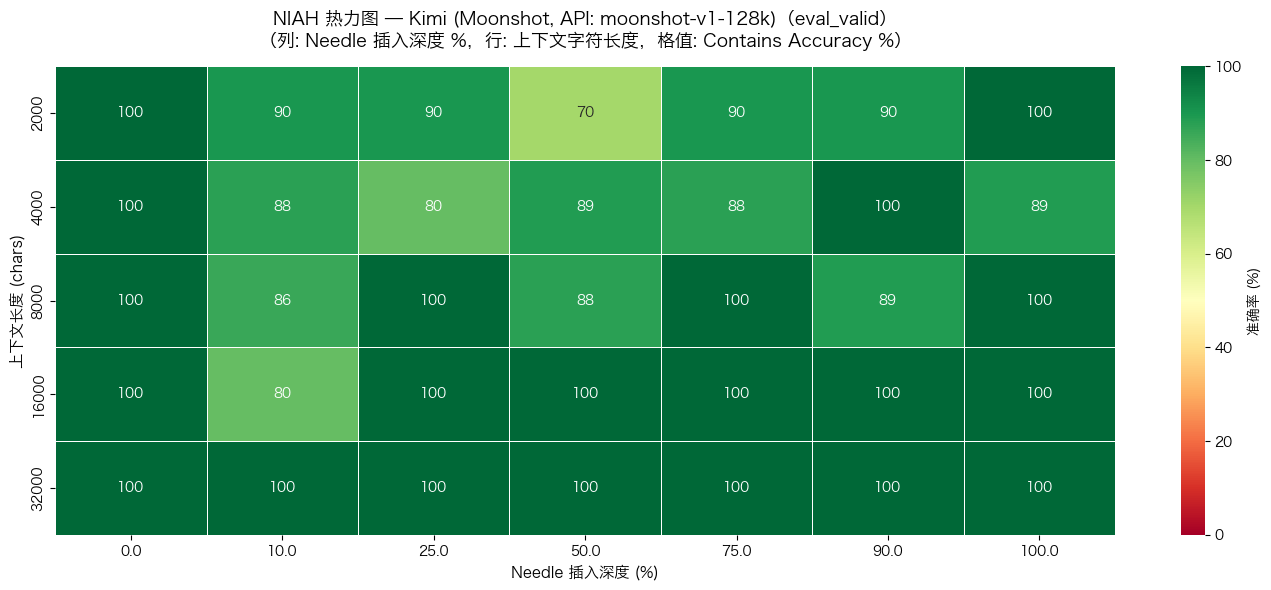

✅ 已保存交互式图表: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_deepseek_interactive.html


✅ 已保存交互式图表: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_qwen_interactive.html


✅ 已保存交互式图表: /Users/melody/Desktop/Eval/results/v2/figures/niah_heatmap_kimi_interactive.html


In [6]:
for model in df_niah['model'].unique():
    plot_niah_heatmap(df_niah, model, save=True, figures_dir=figures_dir, eval_valid_only=True)
    plt.show()

for model in df_niah['model'].unique():
    fig = plot_niah_heatmap_interactive(df_niah, model, save_html=True, figures_dir=figures_dir, eval_valid_only=True)
    fig.show()

## Step 5：长度曲线与效率指标

这一节把准确率、输出 token 和单位命中成本放在一起看。

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/accuracy_by_length.png


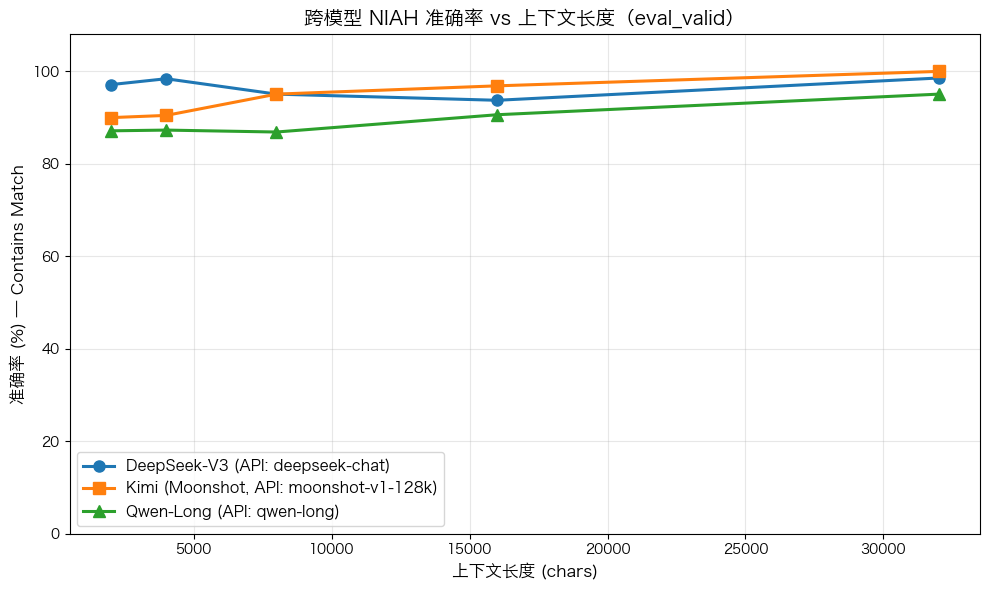

模型级效率指标：


,model,contains_pct,avg_response_chars,avg_completion_tokens,cost_per_contains_hit_cny,contains_per_1k_output_tokens
0,deepseek,96.6,6.5,5.1,0.0057,227.70
2,qwen,89.3,6.6,6.1,0.0397,179.95
1,kimi,94.4,6.8,6.8,0.6388,154.47


In [7]:
fig = plot_accuracy_by_length(df_niah, save=True, figures_dir=figures_dir, eval_valid_only=True)
plt.show()

print('模型级效率指标：')
display(
    model_summary[
        [
            'model', 'contains_pct', 'avg_response_chars', 'avg_completion_tokens',
            'cost_per_contains_hit_cny', 'contains_per_1k_output_tokens',
            ]
        ].sort_values('contains_per_1k_output_tokens', ascending=False)
    )

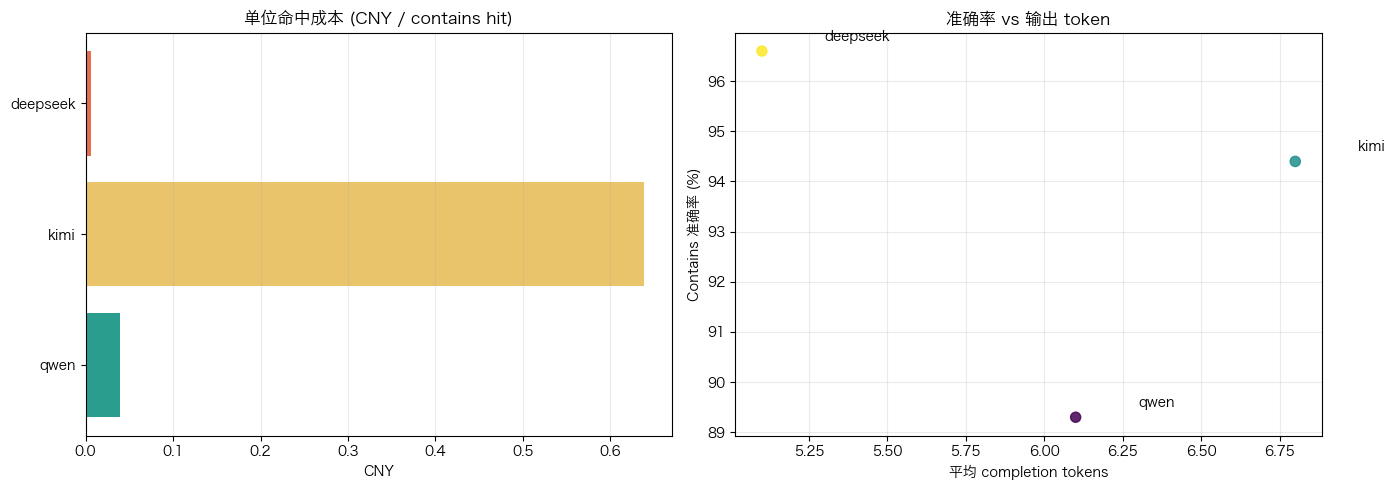

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/efficiency_tradeoff.png


In [8]:
efficiency_plot = model_summary.sort_values('contains_pct', ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    efficiency_plot['model'],
    efficiency_plot['cost_per_contains_hit_cny'],
    color=['#2a9d8f', '#e9c46a', '#e76f51'][:len(efficiency_plot)],
    )
axes[0].set_title('单位命中成本 (CNY / contains hit)')
axes[0].set_xlabel('CNY')
axes[0].grid(True, axis='x', alpha=0.25)

axes[1].scatter(
    efficiency_plot['avg_completion_tokens'],
    efficiency_plot['contains_pct'],
    s=efficiency_plot['avg_response_chars'].clip(lower=1) * 8,
    c=range(len(efficiency_plot)),
    cmap='viridis',
    alpha=0.85,
    )
for _, row in efficiency_plot.iterrows():
    axes[1].text(
        row['avg_completion_tokens'] + 0.2,
        row['contains_pct'] + 0.2,
        row['model'],
        fontsize=10,
        )
axes[1].set_title('准确率 vs 输出 token')
axes[1].set_xlabel('平均 completion tokens')
axes[1].set_ylabel('Contains 准确率 (%)')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
efficiency_path = figures_dir / 'efficiency_tradeoff.png'
fig.savefig(efficiency_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 已保存: {efficiency_path}')

## Step 6：位置偏差与深度趋势

如果 V2 的 style-aligned / multi_key 设计有效，这里应该更容易看出中段衰减是否被放大。

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/position_bias.png


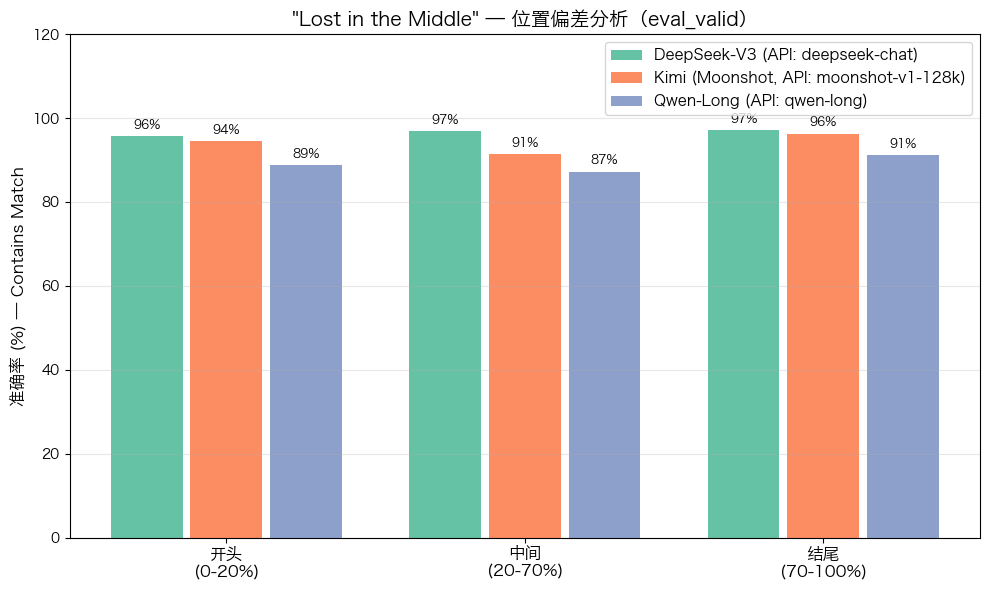

各模型在不同位置的准确率 (%)：


position_bucket,开头,中间,结尾
model,,,
deepseek,88.0,93.0,90.7
kimi,85.0,86.0,86.7
qwen,80.0,82.0,82.0


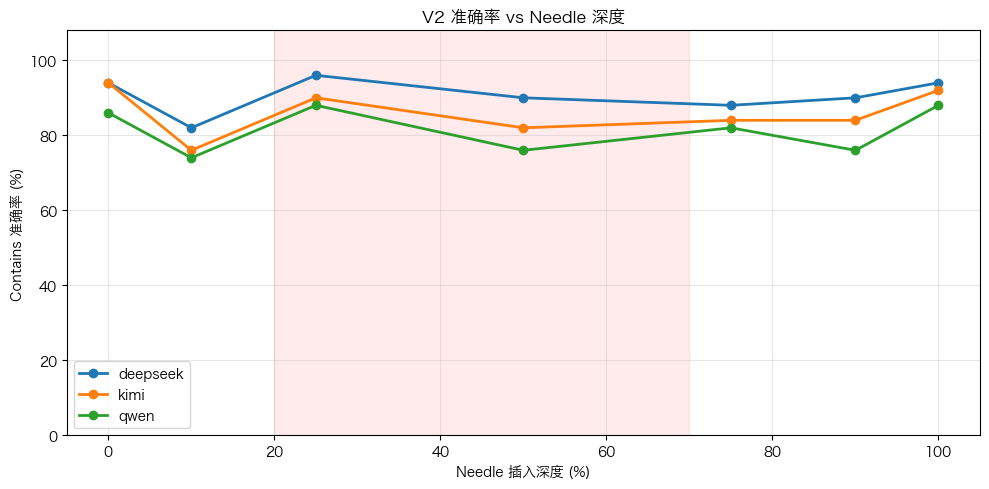

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/depth_accuracy_curve.png


In [9]:
plot_position_bias(df_niah, save=True, figures_dir=figures_dir, eval_valid_only=True)
plt.show()

bins = [-1, 20, 70, 101]
labels = ['开头', '中间', '结尾']
position_df = df_niah.copy()
position_df['position_bucket'] = pd.cut(position_df['depth_pct'], bins=bins, labels=labels)
position_pivot = (
    position_df.groupby(['model', 'position_bucket'], observed=True)['contains_score']
    .mean()
    .unstack(fill_value=0)
    * 100
    ).round(1)

print('各模型在不同位置的准确率 (%)：')
display(position_pivot)

fig, ax = plt.subplots(figsize=(10, 5))
for model, sub in df_niah.groupby('model'):
    depth_acc = sub.groupby('depth_pct')['contains_score'].mean().sort_index() * 100
    ax.plot(depth_acc.index, depth_acc.values, marker='o', linewidth=2, label=model)

ax.axvspan(20, 70, alpha=0.08, color='red')
ax.set_xlabel('Needle 插入深度 (%)')
ax.set_ylabel('Contains 准确率 (%)')
ax.set_title('V2 准确率 vs Needle 深度')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 108)
plt.tight_layout()

depth_curve_path = figures_dir / 'depth_accuracy_curve.png'
fig.savefig(depth_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 已保存: {depth_curve_path}')

多跳推理 — 模型级摘要：


,model,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s
0,deepseek,32,43.8,65.6,48.3,79.6,1.36
1,qwen,32,68.8,68.8,51.4,82.0,0.90


按 hops 拆分（2-hop vs 3-hop）：


,model,hops,n,em_pct,contains_pct
0,deepseek,2.0,27,48.1,74.1
1,deepseek,3.0,5,20.0,20.0
2,qwen,2.0,27,74.1,74.1
3,qwen,3.0,5,40.0,40.0


按领域 Contains 准确率 (%)：


domain
credit_cs        57.1
finance          57.1
healthcare       50.0
manufacturing    83.3
retail           91.7
Name: contains_score, dtype: float64

✅ 已保存: /Users/melody/Desktop/Eval/results/v2/figures/multihop_by_hops.png


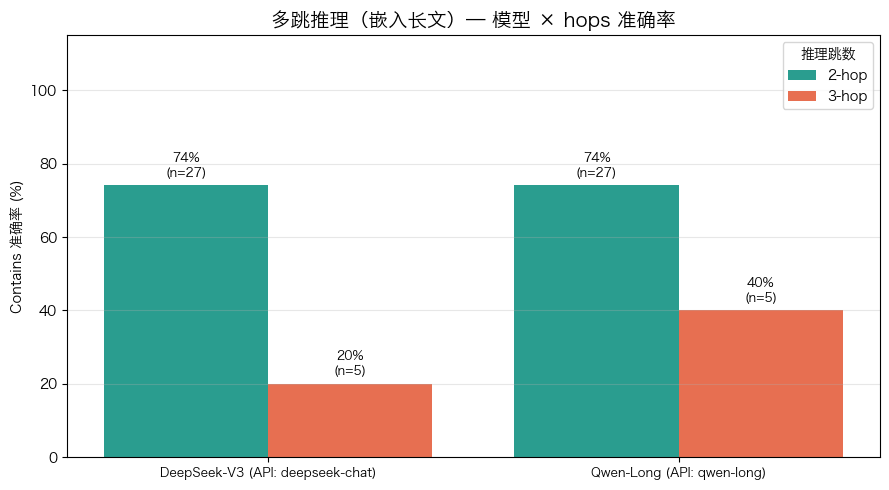

In [10]:
# Step 7：多跳推理（嵌入长文）
# 多跳事实被分散插入 ~8000 字符的中性长文，测试模型跨长距离综合多处信息的能力。
if not df_multihop.empty:
    mh_task = summarize_v2(df_multihop, group_cols=['model', 'task'])
    print('多跳推理 — 模型级摘要：')
    display(mh_task[['model', 'n', 'em_pct', 'contains_pct',
                     'contains_ci_low_pct', 'contains_ci_high_pct', 'avg_latency_s']])

    mh_hops = summarize_v2(df_multihop, group_cols=['model', 'hops'])
    print('按 hops 拆分（2-hop vs 3-hop）：')
    display(mh_hops[['model', 'hops', 'n', 'em_pct', 'contains_pct']])

    mh_domain = (df_multihop.groupby('domain')['contains_score'].mean() * 100).round(1)
    print('按领域 Contains 准确率 (%)：')
    display(mh_domain)

    plot_multihop_by_hops(df_multihop, save=True, figures_dir=figures_dir)
    plt.show()
else:
    print('当前无多跳结果，跳过多跳分析。')


## ✅ V2 分析完成

本 notebook 会把 V2 输出写到 `results/v2/`：
- `results/v2/processed/scored_results.csv`
- `results/v2/processed/summary_by_model.csv`
- `results/v2/processed/summary_by_model_variant.csv`
- `results/v2/processed/summary_by_model_length.csv`
- `results/v2/figures/niah_heatmap_<model>.png`
- `results/v2/figures/accuracy_by_length.png`
- `results/v2/figures/efficiency_tradeoff.png`
- `results/v2/figures/position_bias.png`
- `results/v2/figures/depth_accuracy_curve.png`

⚠️ 如果 Step 1 的 NIAH 覆盖率还没到 100%，结论只能用于观察趋势，不能直接定稿。

下一步：打开 `notebooks/v2/04_report_v2.ipynb` 汇总 V2 结论。